In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp  

In [2]:
P=3
alpha=0.01
sigma=3.5e6
mur=4
mu0=4*np.pi*1e-7

In [3]:
# Exact poles, amp for conducting permable sphere
from scipy.optimize import fsolve
def exactpoleres(sigma,mu,alpha,N):
    poles=np.zeros((N))
    amp=np.zeros((N))
    beta=np.sqrt(sigma*mu)*alpha
    mur=mu/mu0

#   find solutions to fzerofun(deltan,mur) =0 
    Deltan=fsolve(fzerofun, np.pi*np.linspace(1,N,N), args=(mur))
    Deltan=np.sort(Deltan)
    #print(Deltan)
    for n in range(1,N):
        # This is for mu=mu_0
        #deltan2=np.pi**2*n**2
        # This is for general mu
        deltan2=Deltan[n-1]**2
        poles[n]=-deltan2/beta**2
        # This is for mu =mu_0
        #amp[n]=6./(deltan2)
        # For general mu
        amp[n] = 6*mur/((mur+2)*(mur-1)+deltan2)
    return poles,amp

# Residual function to help find solutions to ((mur-1)+deltan2)*(tan deltan ) - (mur-1)*deltan = 0
def fzerofun(deltan,mur):
    return ((mur-1)+deltan**2)*np.tan(deltan) - (mur-1)*deltan



# Exact Step Function Response from a conducting non-permable sphere 
from scipy.optimize import fsolve
def derf(z):
    return 2/np.sqrt(np.pi)*np.exp(-z**2)
# Response from a step function
def exactA(t,sigma,mu,alpha,Npoles):
    mu0 = 4 * np.pi * (1e-7)
    mur=mu/mu0
    beta=np.sqrt(sigma*mu)*alpha
    x=np.sqrt(t)/beta
    T=t/beta**2
    # This is only valid for mur=1
    # Equation (11) Wait + Spies
    #A1=3*(T+1/3-2*np.sqrt(T/np.pi))
    # Method 1
    #for n in range(1,Npoles):
    #    derfn=derf(n/np.sqrt(T))
    #    erfcn=erfc(n/np.sqrt(T))
    #    A1+=-3*2*n*(np.sqrt(T)/n*derfn-2*erfcn)
    # Method 2 (not valid for small T)
    #A2=0.
    #for n in range(1,Npoles):
    #    A2+=6/np.pi**2*np.exp(-np.pi**2*n**2*T)/n**2 # eqn (22) Wait + Spies
    #   find solutions to fzerofun(deltan,mur) =0 

    # Only Method 2 works for permable case
    N=Npoles
    Deltan=fsolve(fzerofun, np.pi*np.linspace(1,N,N), args=(mur))
    Deltan=np.sort(Deltan)
    A2=-2*(mur-1)/(mur+2)
    for n in range(1,Npoles):
        deltan2=Deltan[n-1]**2
        A2+=6*mur/((mur+2)*(mur-1)+ deltan2)*np.exp(-deltan2*T) # eqn (18) Wait + Spies
    A1=A2
    return A1,A2


# Response from a impulse function
def exactB(t,sigma,mu,alpha,Npoles):
    beta=np.sqrt(sigma*mu)*alpha
    x=np.sqrt(t)/beta
    T=t/beta**2
    # Only Method 2 works for permable case
    N=Npoles
    Deltan=fsolve(fzerofun, np.pi*np.linspace(1,N,N), args=(mur))
    Deltan=np.sort(Deltan)
    B2=0.
    for n in range(1,Npoles):
        deltan2=Deltan[n-1]**2
        B2+=-6*mur/((mur+2)*(mur-1)+ deltan2)*deltan2*np.exp(-deltan2*T) # eqn (21) Wait + Spies
    B1=B2
    return B1,B2    



In [4]:
import sympy as sym
def exact_sphere(alpha, epsilon, mur, sigma, omega):
    """
    Function to calculate the mpt for a sphere of radius alpha at radial frequency omega.
    Addapted from a Matlab function from Paul Ledger (exactsphererev5freqscan_nod.m).
    :param omega - Angular frequency rad/s
    :param epsilon - Permittivity:
    :param sigma - Conductivity S/m:
    :param mur - Relative Permeability:
    :param alpha - Sphere radius m:
    :return eig - Single unique eigenvalue of the mpt tensor for a sphere of radius alpha:
    """

    mu0 = 4 * np.pi * (1e-7)
    mu = mur * mu0
    k = np.sqrt((omega ** 2 * epsilon * sigma) + (mu * sigma * omega) * 1j)

    # Using sympy to try to avoid overflow errors.
    k *= alpha
    alpha = alpha

    js_0_kr = sym.sqrt(sym.pi / (2 * k)) * sym.besselj(1 / 2, k)
    js_1_kr = sym.sqrt(sym.pi / (2 * k)) * sym.besselj(3 / 2, k)
    js_2_kr = sym.sqrt(sym.pi / (2 * k)) * sym.besselj(5 / 2, k)
    mpt = (2 * np.pi * alpha ** 3) * (2 * (mu - mu0) * js_0_kr + (2 * mu + mu0) * js_2_kr) / (
        (mu + 2 * mu0) * js_0_kr + (mu - mu0) * js_2_kr)
    return complex(mpt.evalf())

In [5]:
# Select directory
directory="Results/OCC_sphere_prism_4/al_0.01_mu_4_sig_3.5e6/1e1-1e8_40_el_12484_ord_"+str(P)

ck=np.genfromtxt(directory+'/Data/Amplitudes.csv', delimiter=',')
xi=np.genfromtxt(directory+'/Data/Modes.csv', delimiter=',')
Omega=np.genfromtxt(directory+'/Data/Frequencies.csv', delimiter=',')
time=np.genfromtxt(directory+'/Data/Time.csv', delimiter=',')
Sgn_step= np.genfromtxt(directory+'/Data/Sgn_step.csv', delimiter=',')
Sgn_impulse= np.genfromtxt(directory+'/Data/Sgn_impulse.csv', delimiter=',')
TensorArray= np.genfromtxt(directory+'/Data/Tensors.csv', delimiter=',', dtype=complex)
Eigenvalues=np.genfromtxt(directory+'/Data/Eigenvalues.csv', delimiter=',', dtype=complex)
Minf= np.genfromtxt(directory+'/Data/Minf.csv', delimiter=',')
N0= np.genfromtxt(directory+'/Data/N0.csv', delimiter=',')

[6.28277042e-06 6.28278541e-06 6.28276175e-06]


Text(0, 0.5, '-Im$({\\cal M})/(2\\pi \\alpha^3)$')

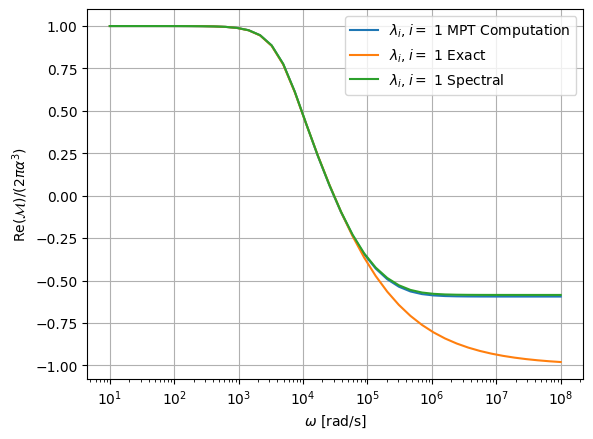

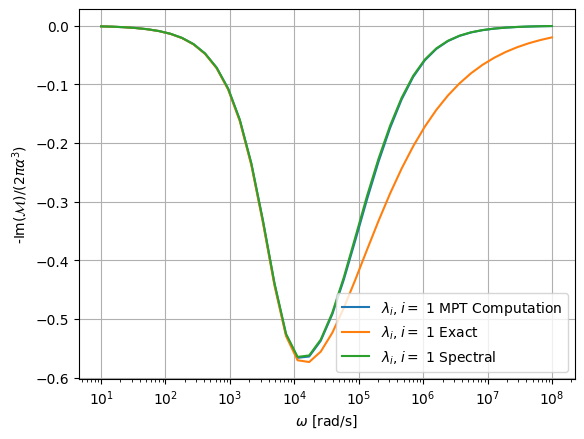

In [6]:
exactMPT=np.zeros(len(Omega),dtype=complex)
# Obtain exact MPT
n=0
for omega in Omega:
    exactMPT[n]=exact_sphere(alpha, 0, mur, sigma, omega)
    n+=1
# Obtain MPT from computed ck,xi
sMPT=np.zeros((len(Omega),3),dtype=complex)
dum,Q=np.linalg.eig(Minf)
lN0=np.diag(np.transpose(Q)@N0@Q)
print(lN0)
n=0
for omega in Omega:
    sMPT[n,:]=lN0[:]
    for k in range(1,len(xi)):
        s=1j*omega
        sk=-xi[k]
        sMPT[n,:]+=-ck[k,:]*(s/(s-sk))
    n=n+1


plt.figure(1)
plt.figure(2)
scale=2*np.pi*alpha**3
for i in range(1):
    plt.figure(1)
    plt.semilogx(Omega,np.real(Eigenvalues[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" MPT Computation")
    plt.semilogx(Omega,np.real(exactMPT)/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" Exact")
    plt.semilogx(Omega,np.real(sMPT[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" Spectral")
            
    plt.figure(2)
    plt.semilogx(Omega,-np.imag(Eigenvalues[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" MPT Computation")
    plt.semilogx(Omega,-np.imag(exactMPT)/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" Exact")
    plt.semilogx(Omega,np.imag(sMPT[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" Spectral")

plt.figure(1)
plt.grid()
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"Re$({\cal M})/(2\pi \alpha^3)$")
plt.legend()

plt.figure(2)
plt.legend()
plt.grid()
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"-Im$({\cal M})/(2\pi \alpha^3)$")


<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/tmp/user/10925/ipykernel_1034926/3432435502.py:13: SyntaxWarning: invalid escape sequence '\l'
  plt.semilogx(time,Sgn_step[:,i]/scale,"r--",label="Numerical step, $\lambda_i$, $i$="+str(i+1))


Text(0, 0.5, '-$\\lambda_i/(2\\pi\\alpha^3)$')

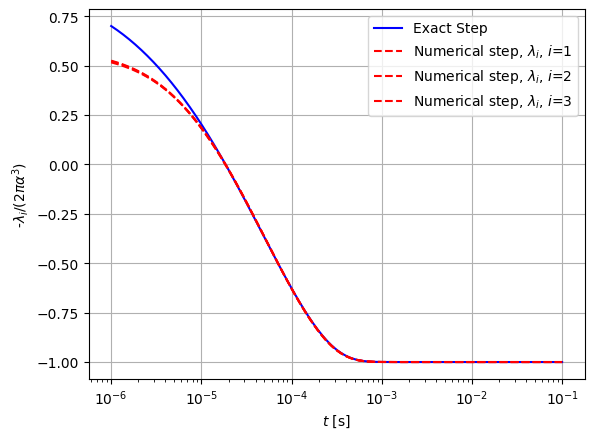

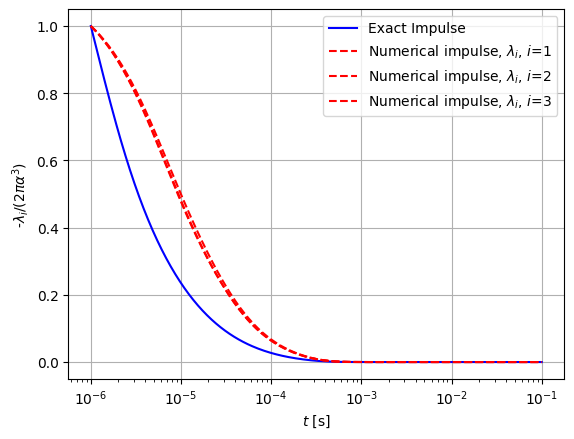

In [7]:
Npoles=20
# Get the exact td step response (Method 2)
_, A2 = exactA(time, sigma, mur*mu0, alpha, Npoles)
l_td_exact_step = A2

# Important note this is -lambda response as it tends to -1 for large time (ie -lambda(N0)(2*pi*alpha^3))
plt.figure(1)
scale=1
plt.semilogx(time, l_td_exact_step /scale , 'b-', label="Exact Step")
scale=2*np.pi*alpha**3
for i in range(3):
    #scale=Sgn_step[0,i]
    plt.semilogx(time,Sgn_step[:,i]/scale,"r--",label="Numerical step, $\lambda_i$, $i$="+str(i+1))
plt.legend()
plt.grid()
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"-$\lambda_i/(2\pi\alpha^3)$")



_, B2 = exactB(time, sigma, mur*mu0, alpha, Npoles)
l_td_exact_impulse = B2

plt.figure(2)
scale=l_td_exact_impulse[0]
plt.semilogx(time, l_td_exact_impulse / scale, 'b-', label="Exact Impulse")
for i in range(3):
    scale=Sgn_impulse[0,i]
    plt.semilogx(time,Sgn_impulse[:,i]/scale,"r--",label=r"Numerical impulse, $\lambda_i$, $i$="+str(i+1))
    
plt.legend()
plt.grid()
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"-$\lambda_i/(2\pi\alpha^3)$")